# Regularization

Regularization is a umbrella term that refers to approaches that help reduce the chance of overfitting, usually either by normalization or through added penatlies.

### 1. Ridge regression ($L_2$ regularization)

Perhaps the most common form of regularization is known as *ridge regression* or $L_2$ *regularization*, sometimes also called *Tikhonov regularization*. This proceeds by penalizing the sum of squares (2-norms) of the model coefficients; in this case, the penalty on the model fit would be 

$$ J(\theta) =  \frac{1}{2}\sum_{i=1}^m(h_\theta(x^{(i)}) - y^{(i)})^2 + \lambda\sum_{j=1}^n \boldsymbol{\theta}_j^2$$

where $\lambda$ is a free parameter that controls the strength of the penalty.

### 2. Lasso regression ($L_1$ regularization)

Another very common type of regularization is known as lasso, and involves penalizing the sum of absolute values (1-norms) of regression coefficients:

$$ J(\theta) = \frac{1}{2}\sum_{i=1}^m(h_\theta(x^{(i)}) - y^{(i)})^2+ \lambda\sum_{j=1}^n |\theta_j|$$

Though this is conceptually very similar to ridge regression, the results can differ surprisingly: that is, lasso regression can set certain features to zero, while ridge regression focuses on shrinking all parameters so it is not overly reliant on one feature.

### 3. Elastic net 

When you lack domain knowledge, you can simply use elastic net.

$$
J(\theta) = \frac{1}{2}\sum_{i=1}^m(h_\theta(x^{(i)}) - y^{(i)})^2 + \lambda \sum_{j=1}^n |\theta_j| + (1 - \lambda) \sum_{k=1}^n \theta_k^2
$$



### Ridge or Lasso or Elastic net??

Regularization should be ALMOST ALWAYS used, since these techniques reduces overfitting.

How to choose is a little bit difficult. It is easier to understand the assumptions behind.
1.  Ridge assumes that coefficients are normally distributed.   **Thus, if you don't want any feature to dominate too much, use Ridge.**
2. Lasso assumes that coefficients are Laplace distributed (in layman sense, it mean some predictors are very useful while some are completely irrelevant).   Here, Lasso has the ability to shrink coefficient to zero thus eliminate predictors that are not useful to the output, thus automatic feature selection.  **In simple words, if you have only very few predictors with medium/large effect, use Lasso.**
3.  Elastic basically is a compromise between the two, and thus take huge computation time to reach that compromise.  **If you have the resource to spare, you can use Elastic net**


## Code

In [488]:
#experiment tracking
import mlflow
import os
# This the dockerized method.
# We build two docker containers, one for python/jupyter and another for mlflow.
# The url `mlflow` is resolved into another container within the same composer.
mlflow.set_tracking_uri("http://localhost:9000")
# In the dockerized way, the user who runs this code will be `root`.
# The MLflow will also log the run user_id as `root`.
# To change that, we need to set this environ["LOGNAME"] to your name.
os.environ["LOGNAME"] = "sushmi"
# mlflow.create_experiment(name="chaky-diabetes-example")  #create if you haven't create
mlflow.set_experiment(experiment_name="sushmi-regularization")

<Experiment: artifact_location='mlflow-artifacts:/215259328580886044', creation_time=1763767449299, experiment_id='215259328580886044', last_update_time=1763767449299, lifecycle_stage='active', name='sushmi-regularization', tags={'mlflow.experimentKind': 'custom_model_development'}>

In [489]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [490]:
df = pd.read_csv("../datasets/Cars.csv")
df_orgin = df.copy()
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [491]:
df.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

In [492]:
df.transmission.value_counts()

transmission
Manual       7078
Automatic    1050
Name: count, dtype: int64

In [493]:
# Defining a mapping of values to numerical encodings
encoding_map = {
    'First Owner': 1,
    'Second Owner': 2,
    'Third Owner': 3,
    'Fourth & Above Owner': 4,
    'Test Drive Car': 5
}

# Encoding the labels in the column 'owner'
df['owner'] = df['owner'].map(encoding_map)

In [494]:
# Saving the values to remove in a array
values_to_remove=['CNG','LPG']
# Reoving the rows with the specified values and reflecting it in the dataframe
df =df[~df['fuel'].isin(values_to_remove)]

In [495]:
# Removing the kmph frpm the records in the column mileage using split such that only the first part of the string is taken while the second part i.e. the kmph (unit) is discarded
df['mileage']=df['mileage'].str.split().str[0]

In [496]:
# Converting the data type of mileage feature to float from string
df['mileage']=df['mileage'].astype(float)

In [497]:
# Removing the CC frpm the records in the column engine using split such that only the first part of the string is taken while the second part i.e. the CC (unit) is discarded
df['engine']= df.engine.str.split().str[0]
# Converting the type of mileage column to float from object (string)
df['engine']=df['engine'].astype(float)

In [498]:
# Removing the bhp frpm the records in the column max_power using split such that only the first part of the string is taken while the second part i.e. thebhp (unit) is discarded
df['max_power']=df.max_power.str.split().str[0]

# Converting max_power to float
df['max_power']=df['max_power'].astype('float')

## Veryfying the type of the column max_power aka power
df['max_power'].dtypes

dtype('float64')

In [499]:
# Renaming and replacing the columns according to convenience
df.rename(columns ={
    'name':'brand'
}, inplace=True)
# Splitting the brand feature and only taking the first part
df['brand']= df.brand.str.split().str[0]
#Veryfying the ouput
df['brand'].head()

0     Maruti
1      Skoda
2      Honda
3    Hyundai
4     Maruti
Name: brand, dtype: object

In [500]:
# Removing the column torque using the drop column function
df=df.drop(['torque'],axis=1)

In [501]:
# Using the query method of data frame which makes a copy from the original dataframe with the query (where owner is not 5 i.e. Test Drive Car) as string and saving it to our dataframe
df=df.query('owner != 5')

In [502]:
# Resetting the index to prepare for our one hot encoding of the brand (name) column
df.reset_index(inplace=True)

In [503]:
df.head()

,index,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,0,Maruti,2014,450000,145500,Diesel,Individual,Manual,1,23.40,1248.0,74.00,5.0
1,1,Skoda,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,5.0
2,2,Honda,2006,158000,140000,Petrol,Individual,Manual,3,17.70,1497.0,78.00,5.0
3,3,Hyundai,2010,225000,127000,Diesel,Individual,Manual,1,23.00,1396.0,90.00,5.0
4,4,Maruti,2007,130000,120000,Petrol,Individual,Manual,1,16.10,1298.0,88.20,5.0


In [504]:
# label encoder for non numeric values
# All features = ['brand', 'year', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats']
from sklearn.preprocessing import LabelEncoder

non_numeric_cols = ['brand', 'fuel', 'seller_type', 'transmission']
le_list = {}
for col in non_numeric_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])  
    le_list[col] = le


In [505]:
# One hot encoding not efficient for high cardinality features like brand (name)
# from sklearn.preprocessing import OneHotEncoder
# """
#         One-hot encodes a categorical feature in a DataFrame.

#     Parameters:
#     - encoder (OneHotEncoder): The OneHotEncoder object fitted on the training data.
#     - dataframe (DataFrame): The DataFrame containing the feature to be one-hot encoded.
#     - feature (str): The name of the categorical feature to be encoded.

#     Returns:
#     - DataFrame: A new DataFrame with the specified feature one-hot encoded and the original feature dropped.
#     """

# # Create function for one-hot encoding a feature in dataframe 
# def one_hot_transform(encoder, dataframe, feature):
#     # Use the encoder to transform the specified feature
#     encoded = encoder.transform(dataframe[[feature]])

#     # Extract the category labels for the feature
#     categories = encoder.categories_[0]
#     # Create a DataFrame with one-hot encoded columns and category labels as column names
#     feature_df = pd.DataFrame(encoded.toarray(), columns=categories[1:])
#     # Concatenate the original DataFrame and the one-hot encoded DataFrame
#     concat_dataframe = pd.concat([dataframe, feature_df], axis=1)
#     # Drop the original feature from the resulting DataFrame
#     return concat_dataframe.drop(feature, axis=1)
    

In [506]:
df.head()

,index,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,0,20,2014,450000,145500,0,1,1,1,23.40,1248.0,74.00,5.0
1,1,27,2014,370000,120000,0,1,1,2,21.14,1498.0,103.52,5.0
2,2,10,2006,158000,140000,1,1,1,3,17.70,1497.0,78.00,5.0
3,3,11,2010,225000,127000,0,1,1,1,23.00,1396.0,90.00,5.0
4,4,20,2007,130000,120000,1,1,1,1,16.10,1298.0,88.20,5.0


In [507]:
# Since 'brand' has multiple value and to prevent the ordinality that comes with it, one-hot encoding is applied to it
# brand_ohe = OneHotEncoder(drop='first').fit(df[['brand']])
# df = one_hot_transform(brand_ohe, df, 'brand')

In [508]:
# Dropping thr column index
df.drop(columns='index', inplace=True)
df

,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,20,2014,450000,145500,0,1,1,1,23.40,1248.0,74.00,5.0
1,27,2014,370000,120000,0,1,1,2,21.14,1498.0,103.52,5.0
2,10,2006,158000,140000,1,1,1,3,17.70,1497.0,78.00,5.0
3,11,2010,225000,127000,0,1,1,1,23.00,1396.0,90.00,5.0
4,20,2007,130000,120000,1,1,1,1,16.10,1298.0,88.20,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
8023,11,2013,320000,110000,1,1,1,1,18.50,1197.0,82.85,5.0
8024,11,2007,135000,119000,0,1,1,4,16.80,1493.0,110.00,5.0
8025,20,2009,382000,120000,0,1,1,1,19.30,1248.0,73.90,5.0
8026,28,2013,290000,25000,0,1,1,1,23.57,1396.0,70.00,5.0


In [509]:
# Excluding one-hot encoded columns
selected_cols = ['year', 'selling_price', 'km_driven', 'fuel', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats', 'brand']
selected_cols_df = df[selected_cols]

selected_cols_df.head()

,year,selling_price,km_driven,fuel,transmission,owner,mileage,engine,max_power,seats,brand
0,2014,450000,145500,0,1,1,23.40,1248.0,74.00,5.0,20
1,2014,370000,120000,0,1,2,21.14,1498.0,103.52,5.0,27
2,2006,158000,140000,1,1,3,17.70,1497.0,78.00,5.0,10
3,2010,225000,127000,0,1,1,23.00,1396.0,90.00,5.0,11
4,2007,130000,120000,1,1,1,16.10,1298.0,88.20,5.0,20


In [510]:
# # Using the distribution plot to get the count of all the numeric features except selling_price
# for col in selected_cols_df.columns:
#     sns.displot(df_orig, x=df_orig[col])
#     plt.title(f'Distribution of {col}')
#     plt.show()


In [511]:
# PLotting the continuous features in the scatter plot against selling_price with fuel as the hue
# for col in df_orig.columns:    
#     sns.scatterplot(x=df_orig[col], y=df['selling_price'], hue=df['fuel'])
#     plt.show()

In [512]:
df_orig.head()

,index,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,0,20,2014,450000,145500,0,1,1,1,23.40,1248.0,74.00,5.0
1,1,27,2014,370000,120000,0,1,1,2,21.14,1498.0,103.52,5.0
2,2,10,2006,158000,140000,1,1,1,3,17.70,1497.0,78.00,5.0
3,3,11,2010,225000,127000,0,1,1,1,23.00,1396.0,90.00,5.0
4,4,20,2007,130000,120000,1,1,1,1,16.10,1298.0,88.20,5.0


<Axes: >

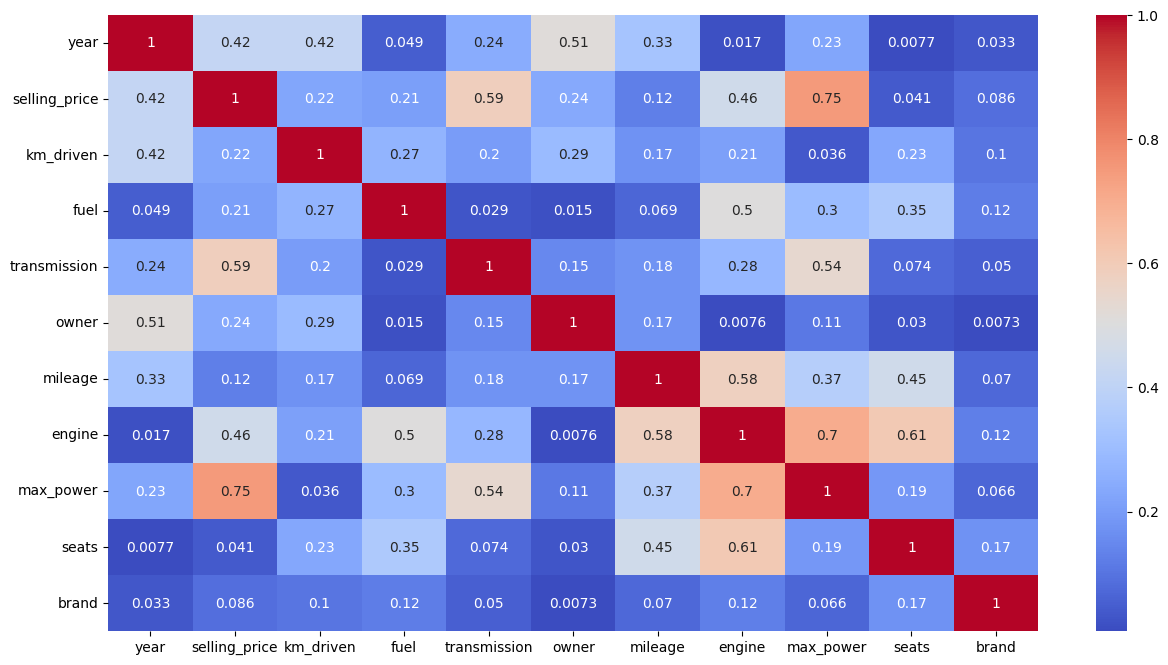

In [513]:
#Correlation matrix to see the correlation between the features
plt.figure(figsize = (15,8))
sns.heatmap(abs(df[selected_cols].corr(numeric_only=True)), annot=True, cmap="coolwarm")

In [514]:
# feature correlation more than equal or more than 40%
feauture_selection_heatmap = ['year', 'transmission', 'engine', 'max_power']

<Axes: xlabel='x', ylabel='y'>

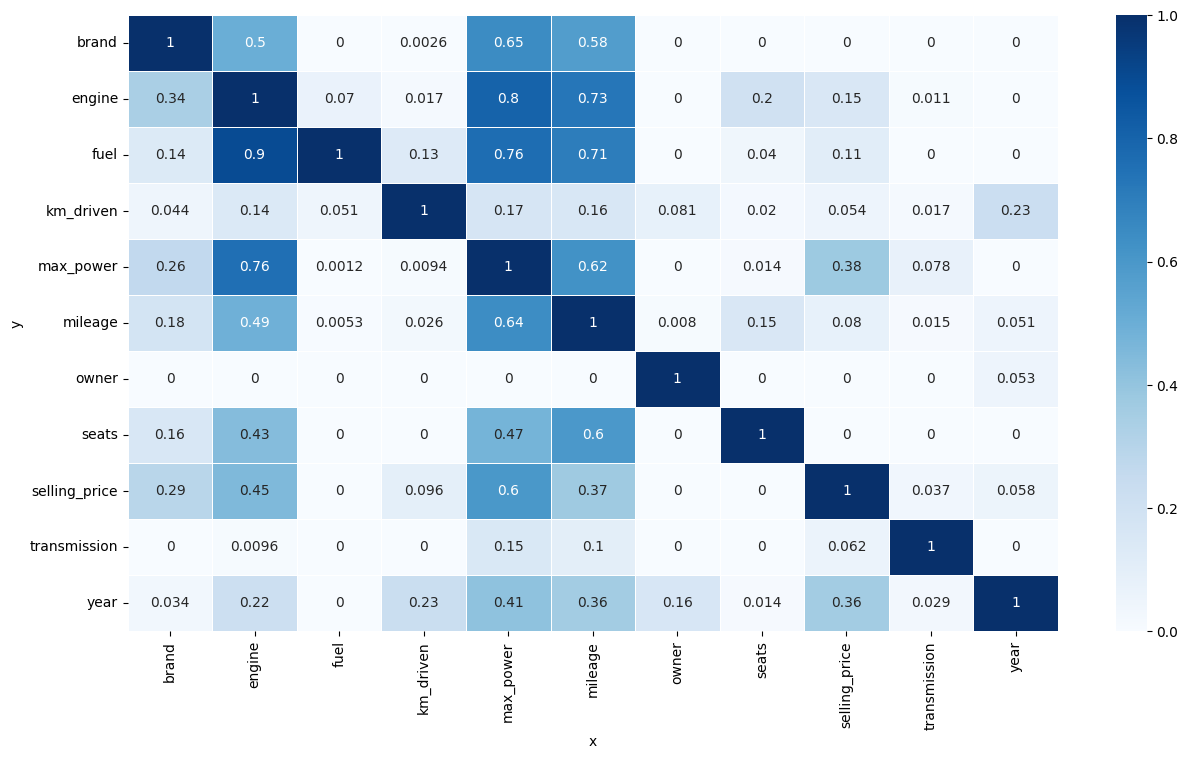

In [515]:
# Predictive power score of features using correlation values
import ppscore as pps

matrix_df = pps.matrix(df[selected_cols])[['x', 'y', 'ppscore']].pivot(columns='x', index='y', values='ppscore')

plt.figure(figsize = (15,8))
sns.heatmap(matrix_df, vmin=0, vmax=1, cmap="Blues", linewidths=0.5, annot=True)

In [516]:
# predicting power more than 10% after rounding to two decimal digits
feature_selection_list = ['brand','engine', 'km_driven', 'max_power', 'mileage', 'year']

feauture_selection_heatmap = ['year', 'transmission', 'engine', 'max_power']

# Combining feature for both graph
selected_features = ['year', 'brand', 'transmission', 'engine', 'km_driven', 'max_power', 'mileage']

selected_features_df = df[selected_features]

selected_features_df.head()


,year,brand,transmission,engine,km_driven,max_power,mileage
0,2014,20,1,1248.0,145500,74.00,23.40
1,2014,27,1,1498.0,120000,103.52,21.14
2,2006,10,1,1497.0,140000,78.00,17.70
3,2010,11,1,1396.0,127000,90.00,23.00
4,2007,20,1,1298.0,120000,88.20,16.10


<Axes: >

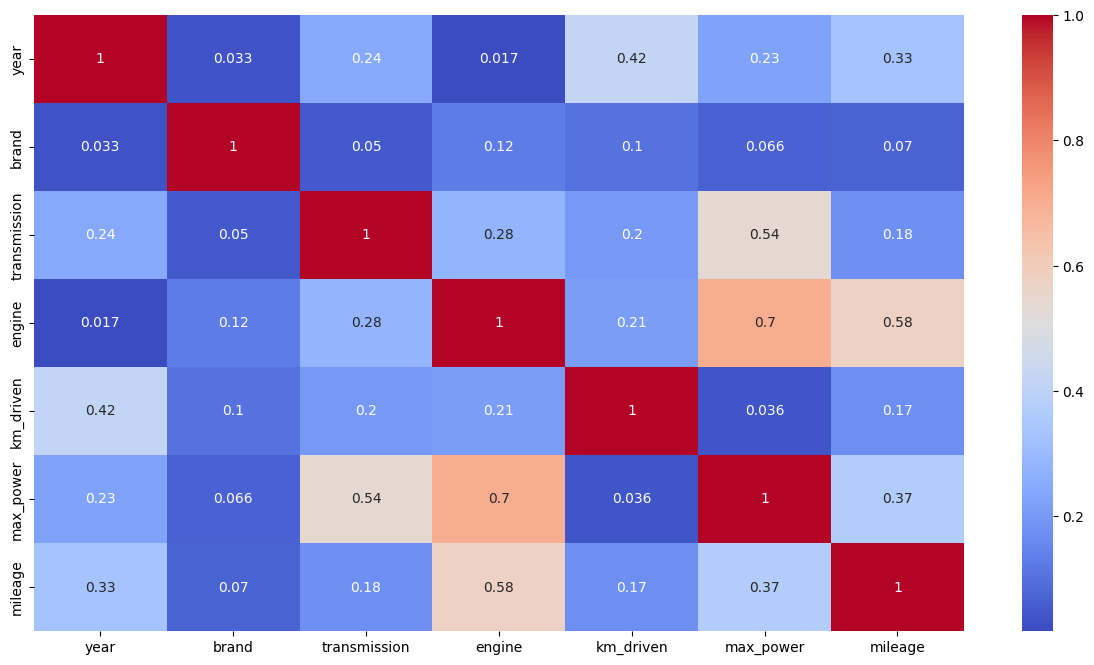

In [517]:
# since we have 7 features, checking if these features are correlated to each other if yes, removing correlated ones.
plt.figure(figsize = (15,8))
sns.heatmap(abs(selected_features_df.corr(numeric_only=True)), annot=True, cmap="coolwarm")


Since there's no strong corellation between any selected features, including all features in training 

# Data Processing

In [518]:
selected_features_df.head()

,year,brand,transmission,engine,km_driven,max_power,mileage
0,2014,20,1,1248.0,145500,74.00,23.40
1,2014,27,1,1498.0,120000,103.52,21.14
2,2006,10,1,1497.0,140000,78.00,17.70
3,2010,11,1,1396.0,127000,90.00,23.00
4,2007,20,1,1298.0,120000,88.20,16.10


In [519]:
selected_features_df.describe()

,year,brand,transmission,engine,km_driven,max_power,mileage
count,8028.000000,8028.000000,8028.000000,7814.000000,8.028000e+03,7820.000000,7814.000000
mean,2013.815521,18.004235,0.869706,1462.914640,6.977314e+04,91.819726,19.391962
std,4.030836,7.388504,0.336648,504.759742,5.664419e+04,35.804513,4.001972
min,1983.000000,0.000000,0.000000,624.000000,1.000000e+03,0.000000,0.000000
25%,2011.000000,11.000000,1.000000,1197.000000,3.500000e+04,68.850000,16.780000
50%,2015.000000,20.000000,1.000000,1248.000000,6.000000e+04,82.400000,19.300000
75%,2017.000000,20.000000,1.000000,1582.000000,9.800000e+04,102.000000,22.320000
max,2020.000000,31.000000,1.000000,3604.000000,2.360457e+06,400.000000,42.000000


In [520]:
# brand_categories = list(brand_ohe.categories_[0][1:])

# # Independent variables, or X or features or predictors or explanatory variables
# # taking significant features based on PSS values >= 0.10 (rounding to 2 decimal places)
# feature_exclude_brand = ['engine', 'km_driven', 'max_power', 'mileage'] 
# selected_features_cols = feature_exclude_brand + brand_categories
# print(brand_categories)
# print(selected_features_cols)
# len(selected_features_cols)


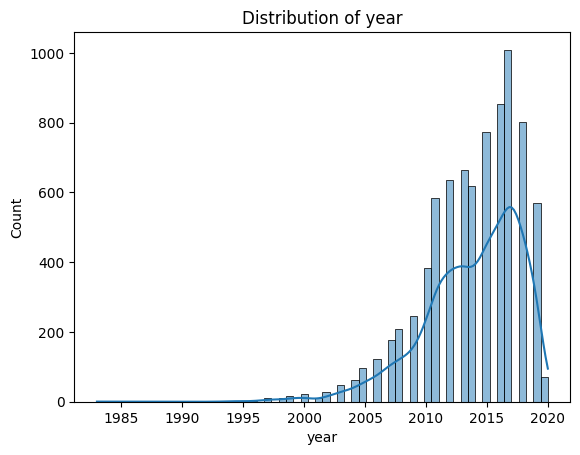

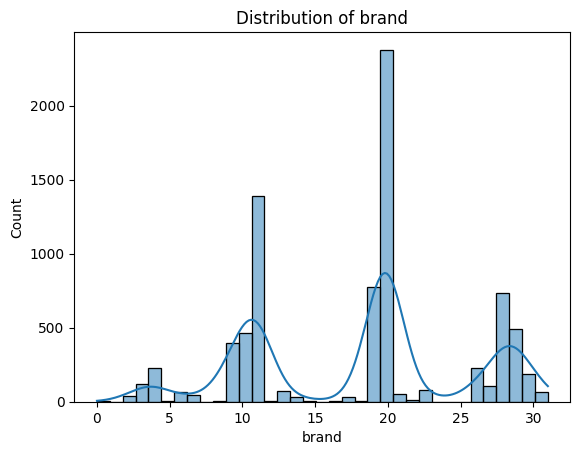

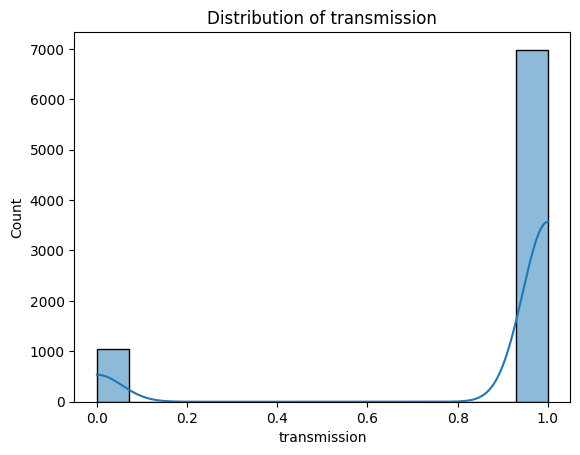

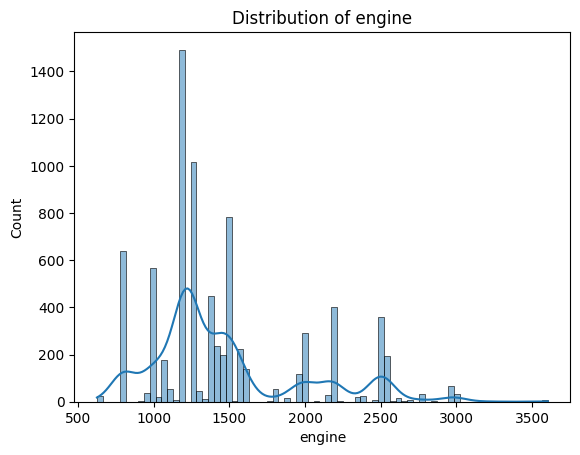

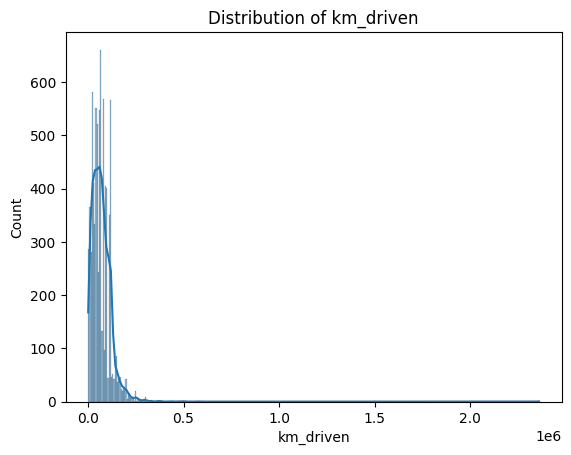

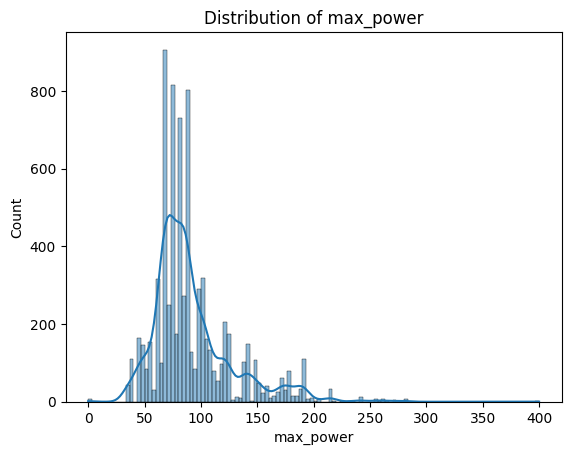

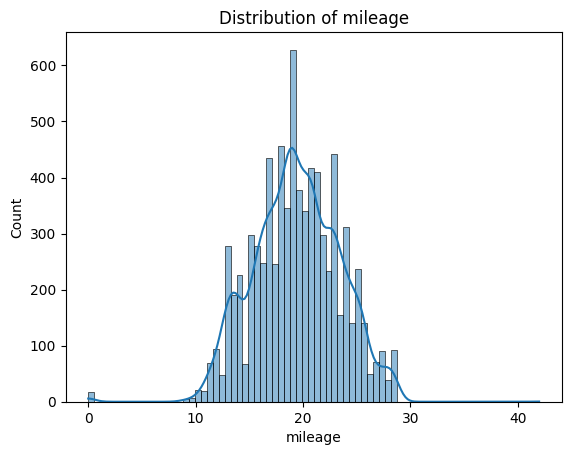

In [521]:
# Scaling features for training
# Learning the distribution before scaling
for col in selected_features_df.columns:
    sns.histplot(df, x=df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

The graph implies - year, brand, transmission and engine are discrete and looks like categorical.

Scaling km_driven, max_power and mileage:

km_driven looks like long tailed normal distribution. Using log to reduce the long tail effect

# Year - changed to old
# brand - drop beacuse we don't have domain knowledge
# engine - can be classified using bin
# km_driven - standardize

# Apply log transformation to reduce long tail effect
price_in_log = np.log1p(df.selling_price)
sns.histplot(price_in_log, kde=True)
plt.title('Distribution of Log-Transformed Car Prices')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')
plt.show()



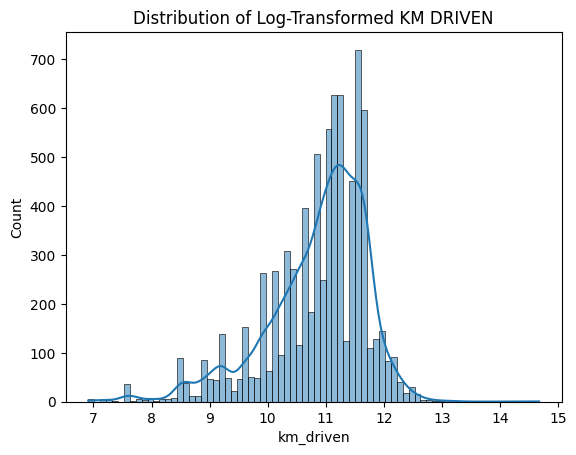

In [522]:
# Apply log transformation to reduce long tail effect
km_driven_log = np.log1p(df.km_driven)
sns.histplot(km_driven_log, kde=True)
plt.title('Distribution of Log-Transformed KM DRIVEN')
plt.show()

### Reasoning and Decisions

`['km_driven', 'max_power','mileage']` => Distribution for these features is almost normal, using Standardization technique can be used for scaling

#### Decision 1: `km_driven` - has long tail, to reduce the tail log transformation will be done before scaling
#### Decision 2: ['km_driven', 'max_power','mileage']` - standard scaling used

`['year', 'brand', 'transmission', 'engine']` => These features' values doesn't look like continuous but discrete. Different techniques will be used to make these feature categorical.


### Feature egineering

1. Year :<br>

OPTION 1: Age (better than boolean old)

<br>OPTION 2: Compute age = max_year - year (numeric). Optionally create boolean old = age > 5, it will be a coarse feature.
Computing age from Year.max() must be consistent between train and test. Prefer using a fixed reference (e.g., current year or dataset max_year computed on the full dataset before the split). Safer: age = current_year - year.

#### Decision 3: Feature engineering for year : Add age column and scale

2. Brand: Since categorizing brand to expensive or cheap requires domain knowledge, dropping from feature selection.

Can think more ?
Check cardinality and predictive power (pps or groupby median target).
If low cardinality (< ~15–20): OneHotEncoder(drop='first') or OneHotEncoder(handle_unknown='ignore').
If high cardinality: frequency encoding, target encoding (with CV), or HashingEncoder. Or drop if brand has no signal.
Always use handle_unknown='ignore' in OneHotEncoder to avoid crash on new brands.

#### Decision 4: Drop `brand`

3. Transmission - No change required, it's a binary feature - either Manual or Automatic

#### Decision 5: NO change for `transmission`

4. Engine: bin (feature engineering)

Example bins: [0, 1000, 1500, 2000, 4000] → labels small/medium/large.
Use sklearn KBinsDiscretizer or pd.cut inside a FunctionTransformer in a Pipeline.
Fill missing engine values first (SimpleImputer with median) then bin.
km_driven: standardize (data processing)

Use StandardScaler or MinMaxScaler depending on model. For linear models StandardScaler often helps.
Fit scaler on training data only and transform test data with same scaler.
Integrate via sklearn Pipeline + ColumnTransformer (recommended)

Prevent leakage by fitting all transformers on X_train only.
Provide imputation for numeric columns (SimpleImputer) before scaling.
Example: numeric pipeline: SimpleImputer(strategy='median') -> StandardScaler(); categorical pipeline: SimpleImputer(strategy='constant', fill_value='missing') -> OneHotEncoder(handle_unknown='ignore').

~~#### Decision 6: feature engineering on `engine` -> use bin~~

 Decision 7 overrides the Decision 6. Engine as a feature is dropped

In [530]:
# Preprocessing of null columns
selected_features_df.isnull().sum()

year              0
transmission      0
engine          214
km_driven         0
max_power       208
mileage         214
dtype: int64

In [533]:
null_columns = selected_features_df.columns.where(selected_features_df.isnull().sum() > 0).dropna()
null_columns

Index(['engine', 'max_power', 'mileage'], dtype='object')

In [523]:
# `['km_driven', 'max_power','mileage']` 
# => Distribution for these features is almost normal, using Standardization technique for scaling
cols_to_standardize = ['km_driven', 'max_power','mileage', 'car_age']

In [524]:
# Drop brand column from selected_cols_df (safe: ignore if missing)
selected_features_df = selected_features_df.drop('brand', axis=1, errors='ignore')

# features/independent variables
X = selected_features_df

# Target: use log of selling_price for numerical stability
y = np.log(df['selling_price'])

# quick check
print("X shape (rows, number of features):", selected_features_df.shape)
print("y shape: (rows)", y.shape)
print(X.head(), y.head())

X shape (rows, number of features): (8028, 6)
y shape: (rows) (8028,)
   year  transmission  engine  km_driven  max_power  mileage
0  2014             1  1248.0     145500      74.00    23.40
1  2014             1  1498.0     120000     103.52    21.14
2  2006             1  1497.0     140000      78.00    17.70
3  2010             1  1396.0     127000      90.00    23.00
4  2007             1  1298.0     120000      88.20    16.10 0    13.017003
1    12.821258
2    11.970350
3    12.323856
4    11.775290
Name: selling_price, dtype: float64


In [525]:
# Train Test Split : Split before imputation and scaling to prevent data leakage
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [534]:
# Impute null columns with mean for numerical columns with normal distribution
from sklearn.impute import SimpleImputer
mean_imputer_list = {}
for col in col_to_impute_by_mean:
    imputer = SimpleImputer(strategy='mean')
    X_train[col] = imputer.fit_transform(X_train[[col]])
    X_test[col] = imputer.transform(X_test[[col]])
    mean_imputer_list[col] = imputer

mean_imputer_list

{'engine': SimpleImputer(),
 'max_power': SimpleImputer(),
 'mileage': SimpleImputer()}

In [538]:
# Check if nulls exists after imputation
assert (X_train.isnull().sum() == 0).all(), "Null values remain in X_train after imputation"
assert (X_test.isnull().sum() == 0).all(), "Null values remain in X_test after imputation"

In [526]:
# Since it's nearly normally distibuted, using Standard scaling
from sklearn.preprocessing import StandardScaler

standard_scaler_list = []

for col in cols_to_standardize:
    scaler = StandardScaler()  
    X_train[col] = scaler.fit_transform(X_train[[col]])
    X_test[col] = scaler.transform(X_test[[col]])
    standard_scaler_list.append((col, scaler))  # Store the scaler for future use

# standard_scaler_list contains the scalers for each column 
standard_scaler_list

[('km_driven', StandardScaler()),
 ('max_power', StandardScaler()),
 ('mileage', StandardScaler())]

In [527]:
# features value after scaling
cols_to_standardize, selected_cols_df.head()

,year,selling_price,km_driven,fuel,transmission,owner,mileage,engine,max_power,seats,brand
0,2014,450000,145500,0,1,1,23.40,1248.0,74.00,5.0,20
1,2014,370000,120000,0,1,2,21.14,1498.0,103.52,5.0,27
2,2006,158000,140000,1,1,3,17.70,1497.0,78.00,5.0,10
3,2010,225000,127000,0,1,1,23.00,1396.0,90.00,5.0,11
4,2007,130000,120000,1,1,1,16.10,1298.0,88.20,5.0,20


In [528]:
# Check if nulls exists after imputation
assert (X_train.isnull().sum() == 0).all(), "Null values remain in X_train after imputation"

(      year  transmission  engine  km_driven  max_power   mileage
 2948  2016             1   799.0  -0.183281  -1.081467  1.439056
 2412  2013             1   796.0  -0.171335  -1.250061  0.834778
 6210  2009             1     NaN  -0.239598        NaN       NaN
 6171  2018             1  2179.0  -0.341993   1.744175 -0.443409
 4201  1999             1  1998.0   0.511297  -0.668410 -1.139697,
       year  transmission  engine  km_driven  max_power   mileage
 5867  2011             1  1368.0  -0.597980  -0.050231 -1.089962
 5957  2016             1  1582.0   0.681955   0.966955  0.071347
 3032  2015             1   998.0  -0.171335  -0.695385  0.280234
 6445  2014             1  1461.0   0.169981   0.468197 -0.092778
 318   2018             1  1186.0  -0.700375  -0.500659  1.148107)

In [529]:
X_train.isnull().sum()

year              0
transmission      0
engine          171
km_driven         0
max_power       165
mileage         171
dtype: int64

In [ ]:
# Feature engineering


In [ ]:
# # 
# df['old'] = abs(df.year - df.year.max()) > 5

# # Year - changed to old
# # brand - drop beacuse we don't have domain knowledge
# # engine - can be classified using bin
# # km_driven - standardize


In [ ]:
# Check null values in X_train
null_train = X_train.isna().sum()
null_train[null_train > 0]

In [ ]:
X_test.isnull().sum().sort_values(ascending=False)

In [ ]:
y_test.isna().sum()

In [ ]:
# Filling null values for max_power
# Let's inspect the distribution plot, mean and median of max_power again
sns.displot(data=df, x='max_power')

print(f"Mean of max_power: {df['max_power'].mean()}")
print(f"Median of max_power: {df['max_power'].median()}")

In [ ]:
# max_power distribution is skewed so missing values are substituted with median
X_train['max_power'].fillna(X_train['max_power'].median(), inplace=True)
X_test['max_power'].fillna(X_train['max_power'].median(), inplace=True)

In [ ]:
# Let's inspect the distribution plot, mean and median of mileage
sns.displot(data=df, x='mileage')

print(f"Mean of mileage: {df['mileage'].mean()}")
print(f"Median of mileage: {df['mileage'].median()}")

In [ ]:
# # mileage distribution is approximately normal so missing values are substituted with mean
# X_train['mileage'].fillna(X_train['mileage'].mean(), inplace=True)
# X_test['mileage'].fillna(X_train['mileage'].mean(), inplace=True)

In [ ]:
# Checking outliers
# Create a dictionary of columns.
#col_dict = {'max_power': 1,'year': 2, 'mileage':3}
col_dict = {'engine': 1, 'km_driven': 2, 'max_power': 3, 'mileage': 4}

# Detect outliers in each variable using box plots.
plt.figure(figsize=(20,30))

for variable,i in col_dict.items():
                     plt.subplot(5,4,i)
                     plt.boxplot(X_train[variable])
                     plt.title(variable)

plt.show()

In [ ]:
def outlier_count(col, data = X_train):
    
    # calculate your 25% quatile and 75% quatile
    q75, q25 = np.percentile(data[col], [75, 25])
    
    # calculate your inter quatile
    iqr = q75 - q25
    
    # min_val and max_val
    min_val = q25 - (iqr*1.5)
    max_val = q75 + (iqr*1.5)
    
    # count number of outliers, which are the data that are less than min_val or more than max_val calculated above
    outlier_count = len(np.where((data[col] > max_val) | (data[col] < min_val))[0])
    
    # calculate the percentage of the outliers
    outlier_percent = round(outlier_count/len(data[col])*100, 2)
    
    if(outlier_count > 0):
        print("\n"+15*'-' + col + 15*'-'+"\n")
        print('Number of outliers: {}'.format(outlier_count))
        print('Percent of data that is outlier: {}%'.format(outlier_percent))

In [ ]:
for col in X_train[['km_driven', 'max_power','mileage']]:
    outlier_count(col)

The outliers are less than 10% , we are ignoring it and processing to scaling

In [ ]:
# Scaling : distribution plots are skewed - Normalization done using min/max scaling

from sklearn.preprocessing import MinMaxScaler

# Define a list of numerical feature names that need to be scaled
num_cols = ['km_driven', 'max_power', 'mileage']

# Create a MinMaxScaler to scale features to a specified range (0 to 1)
scaler = MinMaxScaler(feature_range=(0, 1))

# Scale the numerical features in the training dataset (X_train)
# 1. Compute the scaling parameters (minimum and maximum values) based on the training data
# 2. Apply the scaling transformation to the specified columns in X_train
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# Scale the same numerical features in the test dataset (X_test)
# 1. Use the scaling parameters learned from the training data to transform X_test
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [ ]:
# Let's check shapes of all X_train, X_test, y_train, y_test
print("Shape of X_train: ", X_train.shape)
print("Shape of X_test: ", X_test.shape)
print("Shape of y_train: ", y_train.shape)
print("Shape of y_test: ", y_test.shape)
X_train.isnull().sum().sort_values(ascending=False)



In [ ]:
X_train["engine"]

In [ ]:
sns.displot(df, x=df["engine"].dropna())
plt.title(f'Distribution of engine')
plt.show()

In [ ]:
# Engine values is skewed, so we will use median to fill the missing values
X_train['engine'].fillna(X_train['engine'].median(), inplace=True)

In [ ]:
from sklearn.model_selection import KFold

class LinearRegression(object):

    number_of_kfold = 5
    
    #in this class, we add cross validation as well for some spicy code....
    kfold = KFold(n_splits=number_of_kfold)

    """
    Linear Regression model with gradient descent optimization and regularization.
    Supports batch, stochastic, and mini-batch gradient descent methods.
    """
    def __init__(self, regularization, lr=0.001, method='batch', 
                 init_method= 'xavier', use_momentum=True, momentum= 0.5, 
                 polynomial= True, degree=3,
                 num_epochs=500, batch_size=50, cv=kfold):
        """
        Initialize the LinearRegression model.

        Parameters:
        - regularization: Regularization method (e.g., L1, L2)
        - lr: Learning rate for gradient descent
        - method: Optimization method ('batch', 'sto' for stochastic, 'mini' for mini-batch)
        - init_method: Weight initialization method ('xavier' else 'zero') default is 'xavier' (newly added)
        - use_momentum: Use momentum in gradient descent (True or False) default is True (newly added)
        - momentum: Momentum coefficient (default is 0.5) (newly added)
        - polynomial: Whether to use polynomial feature transformation (default is True) (newly added)
        - degree: Degree of polynomial features
        - num_epochs: Number of training epochs
        - batch_size: Size of mini-batches (for 'mini' method)
        - cv: Cross-validation method (default is 3-fold cross-validation)
        """
        self.regularization = regularization
        self.lr         = lr
        self.method     = method
        self.init_method = init_method
        self.use_momentum = use_momentum
        self.momentum = momentum
        self.polynomial = polynomial
        self.degree = degree
        self.num_epochs = num_epochs
        self.batch_size = batch_size
        self.cv         = cv
        # prev_step will be initialized after theta is created so it matches shape
        self.prev_step  = None
        print(f"""Initialized LinearRegression with {type(self.regularization).__name__} regularization, 
              lr={self.lr}, 
              method={self.method}, 
              init_method={self.init_method}, 
              use_momentum={self.use_momentum},
              momentum={self.momentum},
              polynomial={self.polynomial},
              degree={self.degree},
              num_epochs={self.num_epochs}, 
              batch_size={self.batch_size},
              cv={self.cv.n_splits} folds.""") 
        
    def mse(self, ytrue, ypred):
        return ((ypred - ytrue) ** 2).sum() / ytrue.shape[0]
    
    def r2(self, ytrue, ypred):
        return 1 - ((ytrue - ypred) ** 2).sum() / ((ytrue - ytrue.mean()) ** 2).sum()
    
    def xavier_init(self, dataset):
        size = dataset.shape[0]
        #calculate the range for the weights
        random_weights = np.random.rand(dataset.shape[1])
        #scale them using lower and upper bounds
        lower, upper = -(1.0/np.sqrt(size)), 1.0/np.sqrt(size)
        scaled_weights = lower + random_weights * (upper - lower)
        return scaled_weights
    
    def fit(self, X_train, y_train):
        # store column names if pandas provided (for later feature importance)
        # self.columns = X_train.
        # Store column names first
        if hasattr(X_train, "columns"):
            self.columns = X_train.columns
        else:
            self.columns = [f"x{i}" for i in range(X_train.shape[1])]

        # Convert to numpy arrays
        X_train = np.array(X_train)
        y_train = np.array(y_train).ravel()  # flatten target

        # quick sanity checks
        if np.isnan(X_train).any():
            raise ValueError("NaN found in X_train - please impute or drop missing values before training")
        if np.isnan(y_train).any():
            raise ValueError("NaN found in y_train - please impute or drop missing values before training")

        #create a list of kfold scores
        self.kfold_scores = list()
        
        #reset val loss
        self.val_loss_old = np.inf

        #kfold.split in the sklearn.....
        #5 splits
        for fold, (train_idx, val_idx) in enumerate(self.cv.split(X_train)):
            
            X_cross_train = X_train[train_idx]
            y_cross_train = y_train[train_idx]
            X_cross_val   = X_train[val_idx]
            y_cross_val   = y_train[val_idx]

            if self.init_method == 'xavier':
                self.theta = self.xavier_init(X_cross_train)
            else:
                self.theta = np.zeros(X_cross_train.shape[1]) # zero initialization if not xavier
            
            # ensure momentum buffer matches theta shape
            if self.prev_step is None:
                self.prev_step = np.zeros_like(self.theta)
            
            #one epoch will exhaust the WHOLE training set
            with mlflow.start_run(run_name=f"Fold-{fold}", nested=True):
                
                params = {"method": self.method, "lr": self.lr, "reg": type(self).__name__}
                mlflow.log_params(params=params)
                
                for epoch in range(self.num_epochs):
                
                    #with replacement or no replacement
                    #with replacement means just randomize
                    #with no replacement means 0:50, 51:100, 101:150, ......300:323
                    #shuffle your index
                    perm = np.random.permutation(X_cross_train.shape[0])
                            
                    X_cross_train = X_cross_train[perm]
                    y_cross_train = y_cross_train[perm]
                    
                    if self.method == 'sto':
                        for batch_idx in range(X_cross_train.shape[0]):
                            # keep 2D shape for X and 1D shape for y (size 1) so downstream code is consistent
                            X_method_train = X_cross_train[batch_idx:batch_idx+1, :]
                            y_method_train = y_cross_train[batch_idx:batch_idx+1]
                            train_loss = self._train(X_method_train, y_method_train)
                    elif self.method == 'mini':
                        for batch_idx in range(0, X_cross_train.shape[0], self.batch_size):
                            #batch_idx = 0, 50, 100, 150
                            X_method_train = X_cross_train[batch_idx:batch_idx+self.batch_size, :]
                            y_method_train = y_cross_train[batch_idx:batch_idx+self.batch_size]
                            train_loss = self._train(X_method_train, y_method_train)
                    else:
                        X_method_train = X_cross_train
                        y_method_train = y_cross_train
                        train_loss = self._train(X_method_train, y_method_train)
                    # print(self.method, train_loss)
                    mlflow.log_metric(key="train_loss", value=train_loss, step=epoch)

                    yhat_val = self.predict(X_cross_val)
                    val_loss_new = self.mse(y_cross_val, yhat_val)
                    mlflow.log_metric(key="val_loss", value=val_loss_new, step=epoch)
                    
                    #early stopping
                    if np.allclose(val_loss_new, self.val_loss_old):
                        break
                    self.val_loss_old = val_loss_new
            
                self.kfold_scores.append(val_loss_new)
                print(f"Fold {fold}: {val_loss_new}")
            
                    
    def _train(self, X, y):
        # ensure proper array shapes
        X = np.asarray(X)
        y = np.asarray(y).ravel()

        yhat = self.predict(X)
        yhat = np.asarray(yhat).ravel()
        m    = X.shape[0]

        # gradient (shape: n_features,)
        residual = (yhat - y)
        grad = (X.T @ residual) / m
        if self.regularization:
            grad = grad + self.regularization.derivation(self.theta)

        if hasattr(self, 'use_momentum') and self.use_momentum:
            # compute step and apply momentum
            self.step = self.lr * grad
            self.theta = self.theta - self.step + self.momentum * self.prev_step
            self.prev_step = self.step
        else:
            self.theta = self.theta - self.lr * grad

        return self.mse(y, yhat)
    
    def predict(self, X):
        # coerce to 2D for matrix multiplication and return 1-D predictions
        X = np.asarray(X)
        if X.ndim == 1:
            X = X.reshape(1, -1)
        return (X @ self.theta).ravel()  #===>(m, n) @ (n, ) -> (m,)
    
    def _transform_features(self, X):
       X_poly = np.column_stack([X**i (self.degree)])
       return X_poly
    
    def predict_polynomial(self, X):
        if self.polynomial == True:
            X = self._transform_features(X) #if polynomial is true, then transform the features
        return X @ self.theta  # (m, n_poly) @ (n_poly, )
    
    def _coef(self):
        return self.theta[1:]  #remind that theta is (w0, w1, w2, w3, w4.....wn)
                               #w0 is the bias or the intercept
                               #w1....wn are the weights / coefficients / theta
    def _bias(self):
        return self.theta[0]
    

    def feature_importance(self, width=5, height=10):
        """
        Visualize the feature importance by creating a horizontal bar plot of coefficients.

        Parameters:
        - width: Width of the plot (default is 5)
        - height: Height of the plot (default is 10)

        This method creates a bar plot showing the importance of each feature (coefficient) in the linear regression model.
        It uses the model's coefficients and corresponding feature names to generate the plot. If the model hasn't been trained",
        """
    # Create a DataFrame with coefficients and feature names, if available
        if self.theta is not None and self.columns is not None:
            coefs = pd.DataFrame(data=self.theta, columns=['Coefficients'],index=self.columns) 
            coefs.plot(kind="barh", figsize=(width, height)) # Create a horizontal bar plot
            plt.title("Feature Importance") # Set the title of the plot
            plt.show()  # Display the plot
        else:
            print("Coefficients or feature names are not available to create the graph.")

Now we can create `Ridge`, `Lasso` and `Elastic` class that extends the `LinearRegression`, with added penalty.

In [ ]:
class LassoPenalty:
    
    def __init__(self, l):
        self.l = l # lambda value
        
    def __call__(self, theta): #__call__ allows us to call class as method
        return self.l * np.sum(np.abs(theta))
        
    def derivation(self, theta):
        return self.l * np.sign(theta)
    
class RidgePenalty:
    
    def __init__(self, l):
        self.l = l
        
    def __call__(self, theta): #__call__ allows us to call class as method
        return self.l * np.sum(np.square(theta))
        
    def derivation(self, theta):
        return self.l * 2 * theta
    
class ElasticPenalty:
    
    def __init__(self, l = 0.1, l_ratio = 0.5):
        self.l = l 
        self.l_ratio = l_ratio

    def __call__(self, theta):  #__call__ allows us to call class as method
        l1_contribution = self.l_ratio * self.l * np.sum(np.abs(theta))
        l2_contribution = (1 - self.l_ratio) * self.l * 0.5 * np.sum(np.square(theta))
        return (l1_contribution + l2_contribution)

    def derivation(self, theta):
        l1_derivation = self.l * self.l_ratio * np.sign(theta)
        l2_derivation = self.l * (1 - self.l_ratio) * theta
        return (l1_derivation + l2_derivation)
    
class Lasso(LinearRegression):
    
    def __init__(self, method, lr, l, init_method= 'xavier', use_momentum=True, momentum= 0.5, polynomial= True, degree=3):
        self.regularization = LassoPenalty(l)
        super().__init__(self.regularization, lr, method, init_method, use_momentum, momentum, polynomial, degree)
        
class Ridge(LinearRegression):
    
    def __init__(self, method, lr, l, init_method= 'xavier', use_momentum=True, momentum= 0.5, polynomial= True, degree=3):
        self.regularization = RidgePenalty(l)
        super().__init__(self.regularization, lr, method, init_method, use_momentum, momentum, polynomial, degree)
        
class ElasticNet(LinearRegression):
    
    def __init__(self, method, lr, l, l_ratio=0.5, init_method= 'xavier', use_momentum=True, momentum= 0.5, polynomial= True, degree=3):
        self.regularization = ElasticPenalty(l, l_ratio)
        super().__init__(self.regularization, lr, method, init_method, use_momentum, momentum, polynomial, degree)



class Normal(LinearRegression):
    def __init__(self, method, lr, l, l_ratio=0.5, init_method= 'xavier', use_momentum=True, momentum= 0.5, polynomial= True, degree=3):
        self.regularization = None # No regularization
        super().__init__(self.regularization, lr, method, init_method, use_momentum, momentum, polynomial, degree)



## Experiment

In [ ]:
#helper function for looping classnames
import sys

def str_to_class(classname):
    return getattr(sys.modules[__name__], classname)

In [ ]:
X_train.head(), X_train.columns, X_train.shape, X_train.dtypes

null_train = X_train.isna().sum()

print(null_train > 0)

In [ ]:
nul_test =y_train.isna().sum()
print(nul_test > 0)

In [ ]:
y_train.head(), y_train.shape, y_train.dtypes, y_train.isna().sum(), X_test.isna().sum()


In [ ]:
test_null = X_test.isna().sum()
test_null[test_null > 0]

In [ ]:
# Filling missing values of Mileasege. Before that lets check the distribution of Mileasege
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
sns.histplot(x = 'engine', data = X_train)
plt.title("engine of X_train")
plt.subplot(1,2,2)
sns.histplot(x = 'engine', data = X_test)
plt.title("engine of X_test")
plt.show()

In [ ]:
# since engine is skewed, we will use median to fill the missing values
X_train['engine'] = X_train['engine'].fillna(X_train['engine'].median())
X_test['engine'] = X_test['engine'].fillna(X_test['engine'].median())

In [150]:
# Training model: Fit and Predict 
regs = ["Ridge", "Lasso", "ElasticNet", "Normal"]

learning_rate = 0.01
coefficient = 0.1

for reg in regs:

    params = {"method": "batch", "lr": learning_rate, "l": 0.1, "init_method": "xavier", "use_momentum": True}
    mlflow.start_run(run_name=f"method-{params['method']}-lr-{params['lr']}-reg-{reg}-l-{params['l']}-init_method-{params['init_method']}-momentum-{params['use_momentum']}", nested=True)
    
    print("="*5, reg, "="*5)

    # #######
    type_of_regression = str_to_class(reg)    #Ridge, Lasso, ElasticNet
    model = type_of_regression(**params)  
    model.fit(X_train, y_train)
    yhat = model.predict(X_test)
    mse  = model.mse(y_test, yhat)
    r2 = model.r2(y_test, yhat)

    print("Test MSE: ", mse)
    print("Test R2: ", r2)
    mlflow.log_metric(key="test_mse", value=mse)
    mlflow.log_metric(key="test_r2", value=r2)

    signature = mlflow.models.infer_signature(X_train, model.predict(X_train))
    mlflow.sklearn.log_model(model, artifact_path='model', signature=signature)

    # #######

    mlflow.end_run()

===== Ridge =====
Initialized LinearRegression with RidgePenalty regularization, 
              lr=0.01, 
              method=batch, 
              init_method=xavier, 
              use_momentum=True,
              momentum=0.5,
              polynomial=True,
              degree=3,
              num_epochs=500, 
              batch_size=50,
              cv=5 folds.
Fold 0: 25.229174608300283
🏃 View run Fold-0 at: http://localhost:9000/#/experiments/215259328580886044/runs/96dd355dd2bb43939cfc204ce214c790
🧪 View experiment at: http://localhost:9000/#/experiments/215259328580886044
Fold 1: 28.41032311753644
🏃 View run Fold-1 at: http://localhost:9000/#/experiments/215259328580886044/runs/6ddee555b3a74cb5b2f6edd4d5da2af2
🧪 View experiment at: http://localhost:9000/#/experiments/215259328580886044
Fold 2: 27.543757024993486
🏃 View run Fold-2 at: http://localhost:9000/#/experiments/215259328580886044/runs/45a334223e28447f931aa01059ee498f
🧪 View experiment at: http://localhost:9000/#/exp

2025/11/23 14:32:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Fold 4: 27.43505574761021
🏃 View run Fold-4 at: http://localhost:9000/#/experiments/215259328580886044/runs/8c328e6e6f3246278f495ad57e18064b
🧪 View experiment at: http://localhost:9000/#/experiments/215259328580886044
Test MSE:  24.99451847609736
Test R2:  -34.0976911301917
🏃 View run method-batch-lr-0.01-reg-Ridge-l-0.1-init_method-xavier-momentum-True at: http://localhost:9000/#/experiments/215259328580886044/runs/22c4ceef9e7a4a29bfaa5c99fe4f3d3e
🧪 View experiment at: http://localhost:9000/#/experiments/215259328580886044
===== Lasso =====
Initialized LinearRegression with LassoPenalty regularization, 
              lr=0.01, 
              method=batch, 
              init_method=xavier, 
              use_momentum=True,
              momentum=0.5,
              polynomial=True,
              degree=3,
              num_epochs=500, 
              batch_size=50,
              cv=5 folds.
Fold 0: 17.72171516019456
🏃 View run Fold-0 at: http://localhost:9000/#/experiments/21525932858088

2025/11/23 14:32:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Fold 4: 19.790479008339265
🏃 View run Fold-4 at: http://localhost:9000/#/experiments/215259328580886044/runs/1a51a44e550047a6af47a8f6d4db1e3b
🧪 View experiment at: http://localhost:9000/#/experiments/215259328580886044
Test MSE:  17.21626295635156
Test R2:  -23.17534389534419
🏃 View run method-batch-lr-0.01-reg-Lasso-l-0.1-init_method-xavier-momentum-True at: http://localhost:9000/#/experiments/215259328580886044/runs/cc764a9ddd124fe285abf2cbc6933718
🧪 View experiment at: http://localhost:9000/#/experiments/215259328580886044
===== ElasticNet =====
Initialized LinearRegression with ElasticPenalty regularization, 
              lr=0.01, 
              method=batch, 
              init_method=xavier, 
              use_momentum=True,
              momentum=0.5,
              polynomial=True,
              degree=3,
              num_epochs=500, 
              batch_size=50,
              cv=5 folds.
Fold 0: 19.218626835619766
🏃 View run Fold-0 at: http://localhost:9000/#/experiments/2152

2025/11/23 14:33:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Fold 4: 21.295814055533217
🏃 View run Fold-4 at: http://localhost:9000/#/experiments/215259328580886044/runs/50a8e3fea3d54830a729304c158cc696
🧪 View experiment at: http://localhost:9000/#/experiments/215259328580886044
Test MSE:  18.74837053844509
Test R2:  -25.326753163178978
🏃 View run method-batch-lr-0.01-reg-ElasticNet-l-0.1-init_method-xavier-momentum-True at: http://localhost:9000/#/experiments/215259328580886044/runs/1d91ee910c81440393f73f9f55a13c3c
🧪 View experiment at: http://localhost:9000/#/experiments/215259328580886044
===== Normal =====
Initialized LinearRegression with NoneType regularization, 
              lr=0.01, 
              method=batch, 
              init_method=xavier, 
              use_momentum=True,
              momentum=0.5,
              polynomial=True,
              degree=3,
              num_epochs=500, 
              batch_size=50,
              cv=5 folds.
Fold 0: 17.290127989022924
🏃 View run Fold-0 at: http://localhost:9000/#/experiments/21525932

2025/11/23 14:34:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Fold 4: 19.237229280992885
🏃 View run Fold-4 at: http://localhost:9000/#/experiments/215259328580886044/runs/2dfeca52af774a27847bd7dff4f28aa6
🧪 View experiment at: http://localhost:9000/#/experiments/215259328580886044
Test MSE:  16.666340813764577
Test R2:  -22.403134679766428
🏃 View run method-batch-lr-0.01-reg-Normal-l-0.1-init_method-xavier-momentum-True at: http://localhost:9000/#/experiments/215259328580886044/runs/5bf1ba78366a44308d0e96a2a6099a53
🧪 View experiment at: http://localhost:9000/#/experiments/215259328580886044


## Group Workshop - Check your understandings

| | Egg price | Gold price    | Oil price   | GDP   | $\hat{y}$ |  $(\hat{y} - y)^2$ |
|---:|:------ |:-----------   |:------      |:------|:------    |  :------           |    
| 1  | 3      | 100           | 4           | 21    | 28        |  49                |
| 2  | 4      | 500           | 7           | 43    | 79        |  1296              |
| 3  | 5      | 200           | 6           | 56    | 48        |  64                |
| 4  | 6      | 300           | 8           | 21    | 66        |  2025              |
| 5  | 7      | 400           | 2           | 44    | 60        |  256               |

Note:  this table is filled with given weight of [2, 0.1, 3].

Answer the following questions:

Instruction:  Gather in your group.  Will randomly pick groups to present.

1.  Explain regularization in your own words.
2.  For `LassoPenalty`, show by hand why the derivation is `self.l * np.sign(theta)`
3.  For `RidgePenalty`, show by hand why the derivation is `self.l * 2 * theta`
4.  Using mini-batch gradient descent based on $(\mathbf{x}^{(2)}, \mathbf{x}^{(4)}, \mathbf{x}^{(5)})$, and using **Ridge regression**, what is $J(\theta)$?  Assume $\lambda = 0.1$
5.  Continued from above, what is $\displaystyle \frac{\partial J}{\partial \theta_2}$
6.  Continued from above, what is $\displaystyle \frac{\partial J}{\partial \theta}$
7.  What would be the new theta?
8.  Performed 4,5,6 with **Lasso Regression**.  Assume $\lambda = 0.1$
9.  What does `LinearRegression` inside `Ridge(LinearRegression)` mean?
10. What does `str_to_class` function do?
11. Based on everything you have done in this workshop, what do you think is a good way to decide when to use Ridge, Lasso, or Elastic regression.

## Learnings

1. Fold was returning INF always with 0.001 (learning rate). When printed training loss, it was quite high and increasing. Reducing the learning rate, helped to converge.
2. TODO: Add MSE for each fold 
